# 1. Start with ordinary PyTorch

The first example makes the smallest useful change: keep the model, loss, tensors,
and training loop, but replace a gradient optimizer with PyPerch RHC. The notebook
then builds toward frozen learned features, layer-specific optimizers, and device
behavior.

These seeded runs demonstrate composition, not optimizer rankings. Follow the
[environment setup](../README.md) to run the notebook independently.

In [1]:
import importlib.metadata
import platform
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn

torch.set_num_threads(1)
torch.use_deterministic_algorithms(True)
started = perf_counter()
print("Python", platform.python_version(), "|", platform.system(), platform.machine())
print(
    "Versions:",
    {
        package: importlib.metadata.version(package)
        for package in [
            "pyperch",
            "torch",
            "numpy",
            "matplotlib",
            "scikit-learn",
            "optuna",
        ]
    },
)

Python 3.12.13 | Darwin arm64
Versions: {'pyperch': '0.3.2', 'torch': '2.12.0', 'numpy': '2.2.6', 'matplotlib': '3.10.9', 'scikit-learn': '1.7.2', 'optuna': '4.8.0'}


## Replace the optimizer

With Adam, the optimizer line might be
`torch.optim.Adam(model.parameters(), lr=0.01)`. Replace it with
`RHC(model.parameters(), step_size=0.08, random_state=42)` and provide a closure
that returns training loss. No backward pass is needed because RHC proposes random
parameter changes and keeps only non-increasing training loss.

The example holds out 25% of a generated regression dataset. It prefers CUDA, then
MPS, then CPU, and moves both the model and data to the selected device.

In [2]:
from sklearn.model_selection import train_test_split

from pyperch.optim import RHC
from pyperch.plotting import plot_training_curve, prepare_training_curve

cuda_available = torch.cuda.is_available()
if cuda_available:
    device = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
if not cuda_available:
    print("CUDA unavailable: skipped CUDA execution")
print("RHC device:", device)

rng = np.random.default_rng(42)
X = rng.normal(size=(320, 4)).astype("float32")
y = 1.5 * X[:, 0] - X[:, 1] + 0.5 * X[:, 2] + rng.normal(0, 0.2, 320)
y = y.astype("float32")[:, None]
X_train, X_valid, y_train, y_valid = [
    torch.tensor(array, device=device)
    for array in train_test_split(X, y, test_size=0.25, random_state=42)
]

torch.manual_seed(42)
model = nn.Linear(4, 1).to(device)
loss_fn = nn.MSELoss()
optimizer = RHC(model.parameters(), step_size=0.08, random_state=42)


@torch.no_grad()
def closure():
    return loss_fn(model(X_train), y_train)


losses = {"Train": [], "Validation": []}
for _ in range(200):
    optimizer.step(closure)
    with torch.no_grad():
        losses["Train"].append(loss_fn(model(X_train), y_train).item())
        losses["Validation"].append(loss_fn(model(X_valid), y_valid).item())

optimizer.restore_best()
with torch.no_grad():
    restored_mse = loss_fn(model(X_valid), y_valid).item()
reference_mse = ((y_valid - y_train.mean()) ** 2).mean().item()
print(
    f"Restored validation MSE: {restored_mse:.4f}; "
    f"constant reference: {reference_mse:.4f}"
)
print(
    f"RHC calls / measured objective evaluations: 200 / "
    f"{optimizer.function_evals}; proposals accepted / rejected: "
    f"{optimizer.accepted_steps} / {optimizer.rejected_steps}"
)

CUDA unavailable: skipped CUDA execution
RHC device: mps


Restored validation MSE: 0.0486; constant reference: 3.3505
RHC calls / measured objective evaluations: 200 / 200; proposals accepted / rejected: 40 / 159


The training curve records the current model after every RHC call. Its flat
segments are rejected proposals, the visible signature of greedy local search.
`restore_best()` is called before the reported validation MSE. Here one RHC call
costs one measured objective evaluation, including the initial loss evaluation.
The restored validation MSE is 0.0486 versus 3.3505 for the dotted constant
reference.

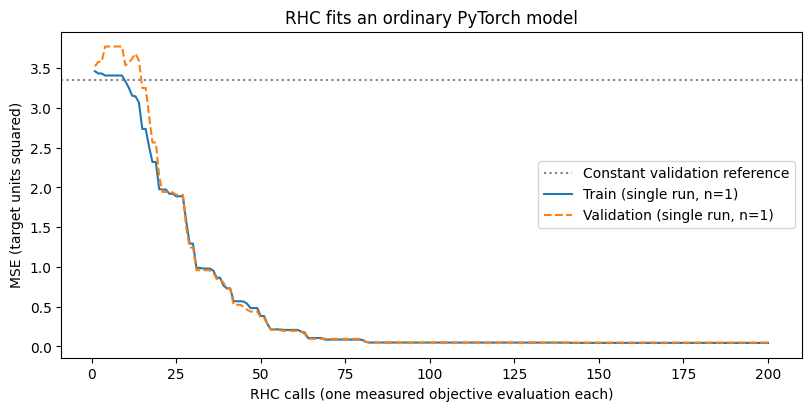

In [3]:
curve = prepare_training_curve(
    np.arange(1, 201),
    losses,
    metric="MSE (target units squared)",
    x_label="RHC calls (one measured objective evaluation each)",
)
fig, ax = plt.subplots(figsize=(8, 4), layout="constrained")
ax.axhline(
    reference_mse,
    color="gray",
    linestyle=":",
    label="Constant validation reference",
)
plot_training_curve(curve, ax=ax)
ax.set_title("RHC fits an ordinary PyTorch model")
plt.show()

## Freeze learned features and optimize the head

Train a digits classifier for 16 full-batch Adam updates, then freeze its two
feature layers and give only the classifier head to RHC. The short Adam stage is a
partially trained starting point, not a comparison baseline. Training-only scaling
keeps validation information out of fitting.

In [4]:
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler

digits = load_digits()
X_train_np, X_valid_np, y_train_np, y_valid_np = train_test_split(
    digits.data,
    digits.target,
    test_size=0.25,
    stratify=digits.target,
    random_state=42,
)
scaler = StandardScaler().fit(X_train_np)
X_train = torch.tensor(scaler.transform(X_train_np), dtype=torch.float32)
X_valid = torch.tensor(scaler.transform(X_valid_np), dtype=torch.float32)
y_train = torch.tensor(y_train_np, dtype=torch.long)
y_valid = torch.tensor(y_valid_np, dtype=torch.long)


def make_model():
    return nn.Sequential(
        nn.Linear(64, 24),
        nn.ReLU(),
        nn.Linear(24, 12),
        nn.ReLU(),
        nn.Linear(12, 10),
    )


@torch.no_grad()
def classification_metrics(model):
    measured_losses = {
        "Train": loss_fn(model(X_train), y_train).item(),
        "Validation": loss_fn(model(X_valid), y_valid).item(),
    }
    validation_accuracy = (model(X_valid).argmax(1) == y_valid).float().mean().item()
    return measured_losses, validation_accuracy


torch.manual_seed(42)
model = make_model()
loss_fn = nn.CrossEntropyLoss()
adam = torch.optim.Adam(model.parameters(), lr=0.01)
initial_losses, _ = classification_metrics(model)
adam_losses = {name: [value] for name, value in initial_losses.items()}

for _ in range(16):
    adam.zero_grad()
    loss = loss_fn(model(X_train), y_train)
    loss.backward()
    adam.step()
    current_losses, _ = classification_metrics(model)
    for name in adam_losses:
        adam_losses[name].append(current_losses[name])

before_rhc_losses, before_rhc_accuracy = classification_metrics(model)
feature_parameters = list(model[0].parameters()) + list(model[2].parameters())
frozen_features = [parameter.detach().clone() for parameter in feature_parameters]
for parameter in feature_parameters:
    parameter.requires_grad_(False)

optimizer = RHC(model[4].parameters(), step_size=0.025, random_state=42)


@torch.no_grad()
def closure():
    return loss_fn(model(X_train), y_train)


rhc_losses = {name: [value] for name, value in before_rhc_losses.items()}
for _ in range(151):
    optimizer.step(closure)
    current_losses, _ = classification_metrics(model)
    for name in rhc_losses:
        rhc_losses[name].append(current_losses[name])

optimizer.restore_best()
after_rhc_losses, after_rhc_accuracy = classification_metrics(model)
assert all(
    torch.equal(before, after)
    for before, after in zip(frozen_features, feature_parameters)
)
assert np.isclose(after_rhc_losses["Train"], optimizer.best_loss)
print("Frozen feature parameters unchanged exactly.")
print(
    f"Validation accuracy before RHC: {before_rhc_accuracy:.3f}; "
    f"after restoring RHC's best state: {after_rhc_accuracy:.3f}"
)
print(
    f"Validation loss before RHC: {before_rhc_losses['Validation']:.3f}; "
    f"after restore: {after_rhc_losses['Validation']:.3f}"
)

Frozen feature parameters unchanged exactly.
Validation accuracy before RHC: 0.789; after restoring RHC's best state: 0.820
Validation loss before RHC: 0.834; after restore: 0.699


The saved run reaches 0.789 validation accuracy while both Adam losses are still
falling. RHC then lowers head-only training loss in discrete accepted steps; after
checkpoint restoration, validation accuracy is 0.820 and validation loss falls from
0.834 to 0.699. The frozen-feature assertion makes parameter ownership explicit.

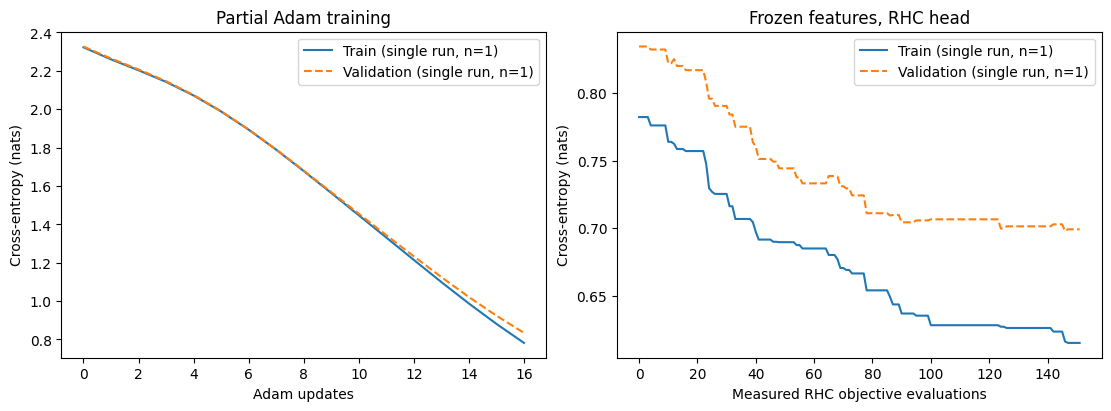

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), layout="constrained")
for ax, x, scores, title, x_label in [
    (axes[0], np.arange(17), adam_losses, "Partial Adam training", "Adam updates"),
    (
        axes[1],
        np.arange(152),
        rhc_losses,
        "Frozen features, RHC head",
        "Measured RHC objective evaluations",
    ),
]:
    curve = prepare_training_curve(
        x,
        scores,
        metric="Cross-entropy (nats)",
        x_label=x_label,
    )
    plot_training_curve(curve, ax=ax)
    ax.set_title(title)
plt.show()

## Give different layers different optimizers

Continue from the restored head. Keep the first layer frozen, update the second
feature layer with Adam, and update the classifier with RHC. Each cycle uses one
Adam update followed by a fresh three-call RHC search on the head. Recreating RHC
after Adam changes shared model behavior ensures its cached objective starts from
the current model.

In [6]:
for parameter in model[2].parameters():
    parameter.requires_grad_(True)

frozen_first_layer = [parameter.detach().clone() for parameter in model[0].parameters()]
adam = torch.optim.Adam(model[2].parameters(), lr=0.002)
hybrid_losses = {name: [value] for name, value in after_rhc_losses.items()}
hybrid_before_accuracy = after_rhc_accuracy

for cycle in range(20):
    model.zero_grad(set_to_none=True)
    loss = loss_fn(model(X_train), y_train)
    loss.backward()
    adam.step()

    rhc = RHC(model[4].parameters(), step_size=0.015, random_state=1000 + cycle)
    for _ in range(3):
        rhc.step(closure)
    rhc.restore_best()

    current_losses, _ = classification_metrics(model)
    for name in hybrid_losses:
        hybrid_losses[name].append(current_losses[name])

hybrid_after_losses, hybrid_after_accuracy = classification_metrics(model)
assert all(
    torch.equal(before, after)
    for before, after in zip(frozen_first_layer, model[0].parameters())
)
print("Frozen first-layer parameters unchanged exactly.")
print(
    f"Hybrid validation accuracy before: {hybrid_before_accuracy:.3f}; "
    f"after: {hybrid_after_accuracy:.3f}"
)
print(
    f"Hybrid validation loss before: {after_rhc_losses['Validation']:.3f}; "
    f"after: {hybrid_after_losses['Validation']:.3f}"
)

Frozen first-layer parameters unchanged exactly.
Hybrid validation accuracy before: 0.820; after: 0.842
Hybrid validation loss before: 0.699; after: 0.582


Both losses fall across the saved hybrid run: validation loss moves from 0.699 to
0.582 and accuracy from 0.820 to 0.842, while the first layer remains unchanged. A
cycle is a mixed budget: one gradient update plus three RHC objective evaluations,
of which one initializes RHC and two propose head changes. It is not equivalent to
a pure Adam or pure RHC iteration.

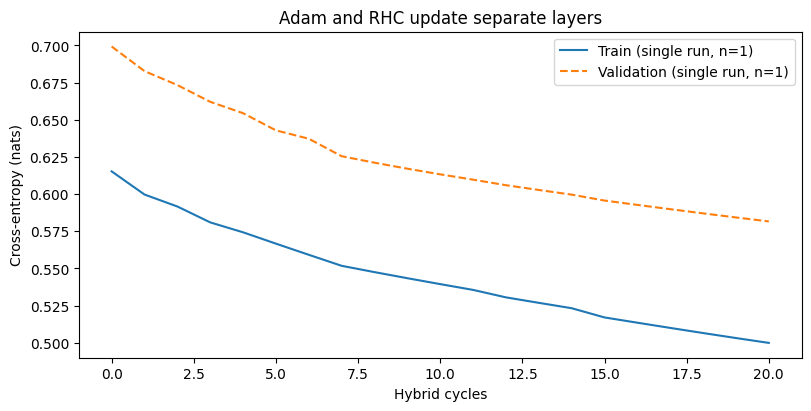

In [7]:
fig, ax = plt.subplots(figsize=(8, 4), layout="constrained")
curve = prepare_training_curve(
    np.arange(21),
    hybrid_losses,
    metric="Cross-entropy (nats)",
    x_label="Hybrid cycles",
)
plot_training_curve(curve, ax=ax)
ax.set_title("Adam and RHC update separate layers")
plt.show()

Next: [illustrative optimizer comparison](02_optimizer_comparison.ipynb).

In [8]:
print(f"Notebook computation and plotting: {perf_counter() - started:.2f} seconds")

Notebook computation and plotting: 1.30 seconds
